# Bài tập thực hành tuần 1
> Họ và tên: Nguyễn Vạn Phúc Huy <br>
> MSSV: 23110163 <br>
> Lớp: 23TTH_KDL2

This is a dataset related to how much money a person can get from a mortgage on his or her home. This dataset includes the following features:
* Gender: Gender of the borrower (including two values 'F' and 'M')
* Age: Age of the customer applying for a loan (including positive integer values)
* Income (USD): Customer's income in USD (value is a positive number)
* Income Stability: The level of customer's income stability (including three values of Low and High)
* Property Age: Life expectancy of the house in days (including positive integer values)
* Property Location: Location of the house (including 'Rural', 'Urban', and 'Semi-Urban')
* Property Price: The value of the house in USD (including positive real values)
* Loan Sanction Amount (USD): Amount that customers can borrow in USD (target value)

Based on practice sample #1, proceed:
1. Read data
2. Visualize some information of data
3. Normalize Data (Feature Engineering) to train linear regression model
4. Train linear regression model and show the model's intercepts, coeficients
5. Learn on sklearn how to use Ridge, Lasso, and ElasticNet compare the error of all 3 algorithms with Linear Regression (https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
6. Let's try Polynomial of order 2 to compare the previous results. What will the result be if we choose the n order too high?


In [49]:
#import library
import pandas as pd # pandas
import numpy as np # numpy
import seaborn as sns # seaborn
import matplotlib.pyplot as plt # matplotlib
import time
from scipy.stats import zscore
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn import linear_model




# 1. Read Data

In [50]:
# read data using Pandas DataFrame
def read_dataset(path):
    df = pd.read_csv(path)
    display(df.head())
    print("\nDataFrame Info:")
    print(df.info())
    print("\nDataFrame Shape:", df.shape)
    display(df.describe())
    return df

In [51]:
path = r"D:\Introduction-to-Machine-Learning_MTH10353\Homework\1\final_house_loan.csv"
path = r"C:\Users\lenovo\OneDrive\Document\Introduction-to-Machine-Learning_MTH10353\Homework\1\final_house_loan.csv"

In [52]:
df = read_dataset(path)

,Gender,Age,Income (USD),Income Stability,Property Age,Property Location,Property Price,Loan Sanction Amount (USD)
0,F,19,1641.25,Low,1651.25,Rural,59641.82,21026.420753
1,M,29,1989.71,Low,1990.71,Urban,179858.51,60595.183366
2,F,37,1849.91,Low,1856.91,Rural,117297.62,39181.648002
3,M,65,2735.18,High,2747.18,Rural,354417.72,128497.710865
4,F,62,4741.78,High,4740.78,Urban,82049.80,39386.919336



DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47297 entries, 0 to 47296
Data columns (total 8 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Gender                      47297 non-null  object 
 1   Age                         47297 non-null  int64  
 2   Income (USD)                47265 non-null  float64
 3   Income Stability            47285 non-null  object 
 4   Property Age                47263 non-null  float64
 5   Property Location           47294 non-null  object 
 6   Property Price              47297 non-null  float64
 7   Loan Sanction Amount (USD)  47297 non-null  float64
dtypes: float64(4), int64(1), object(3)
memory usage: 2.9+ MB
None

DataFrame Shape: (47297, 8)


,Age,Income (USD),Property Age,Property Price,Loan Sanction Amount (USD)
count,47297.000000,47265.000000,47263.000000,4.729700e+04,47297.000000
mean,40.000063,2586.684384,2586.611058,1.350880e+05,46487.229765
std,16.086128,1558.768809,1558.842286,9.457875e+04,32549.905634
min,18.000000,372.700000,370.700000,7.859620e+03,254.586578
25%,24.000000,1653.740000,1652.820000,6.250408e+04,21782.822159
50%,40.000000,2245.480000,2244.810000,1.130936e+05,38822.132402
75%,55.000000,3128.560000,3128.380000,1.819546e+05,62612.236905
max,65.000000,54662.750000,54647.750000,1.077967e+06,366131.165218


# 2. Visualize some information of data

**Extra:**  check missing values & null values


In [53]:
# Check for missing values in the dataset
print("Missing values summary:")
display(df.isnull().sum())

Missing values summary:


Gender                         0
Age                            0
Income (USD)                  32
Income Stability              12
Property Age                  34
Property Location              3
Property Price                 0
Loan Sanction Amount (USD)     0
dtype: int64

In [54]:
def preprocessing_data(df):
    # fill missing values with mean for numeric columns
    df = df.fillna(df.mean(numeric_only=True))
    # fill missing values with mode for categorical columns
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            df[col] = df[col].fillna(df[col].mode().iloc[0])
    return df

df = preprocessing_data(df)
print("Missing values after preprocessing:")
display(df.isnull().sum())

Missing values after preprocessing:


Gender                        0
Age                           0
Income (USD)                  0
Income Stability              0
Property Age                  0
Property Location             0
Property Price                0
Loan Sanction Amount (USD)    0
dtype: int64

Visualize the distribution of data using histograms and boxplots to understand the spread and identify any potential outliers.

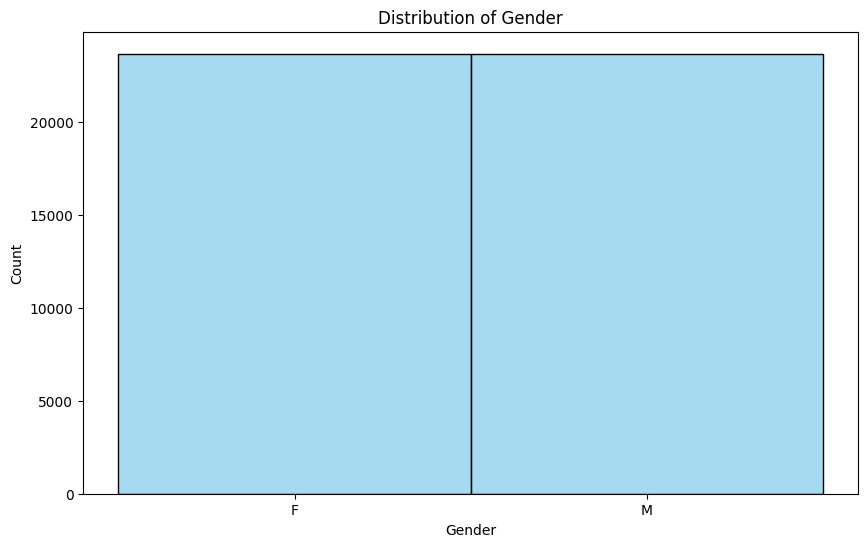

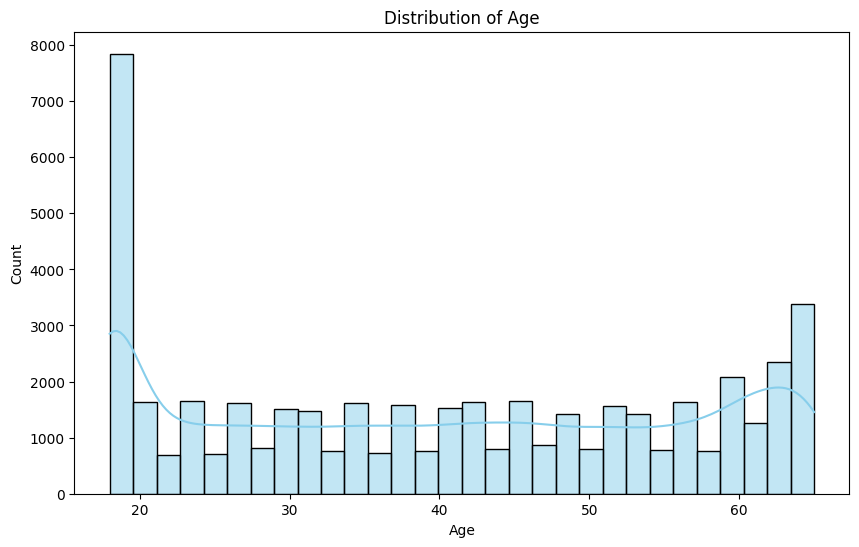

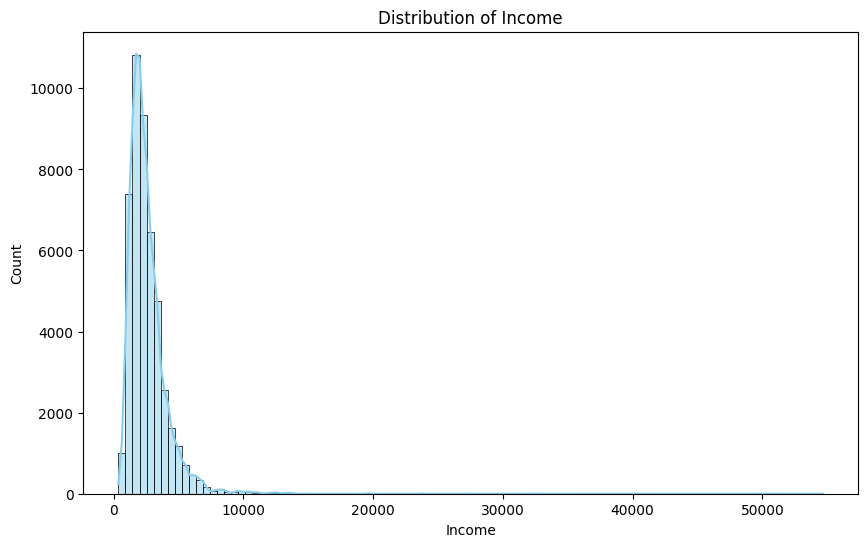

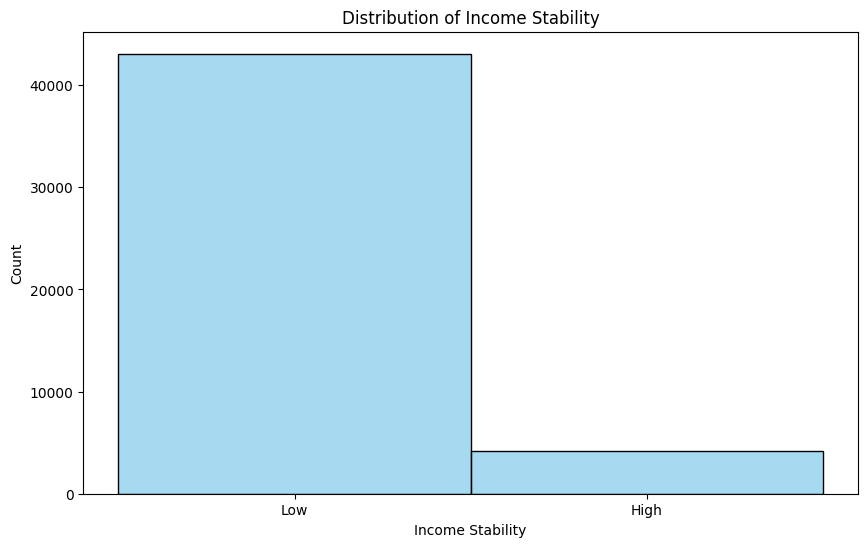

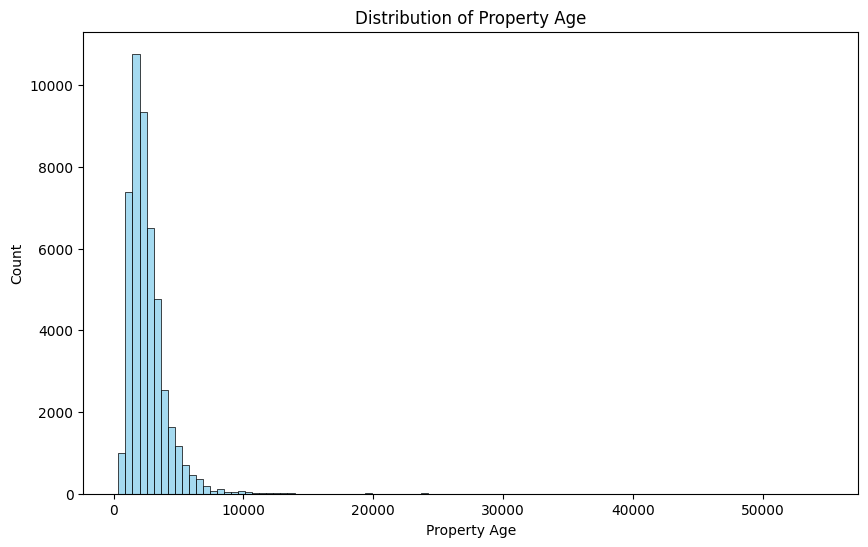

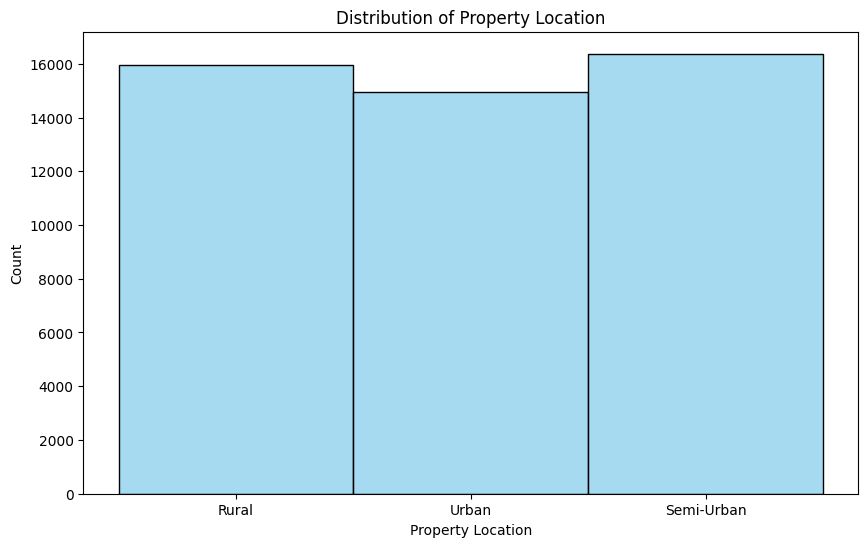

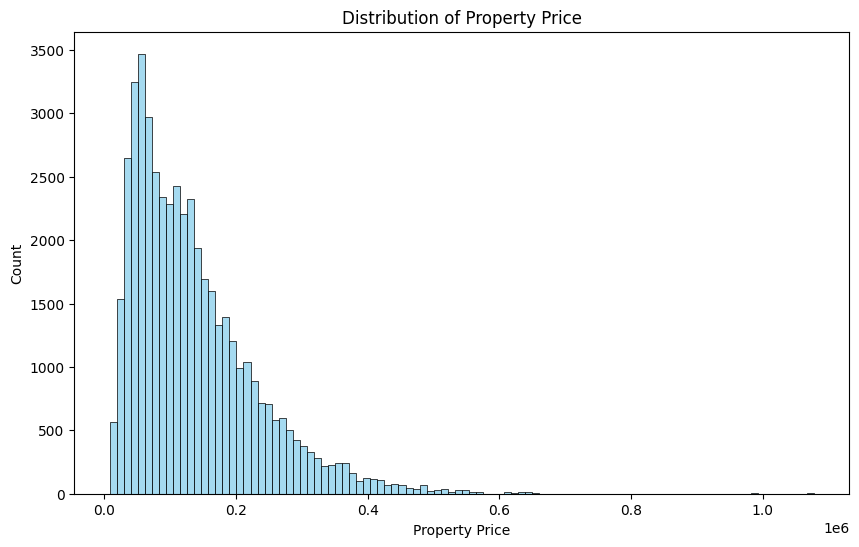

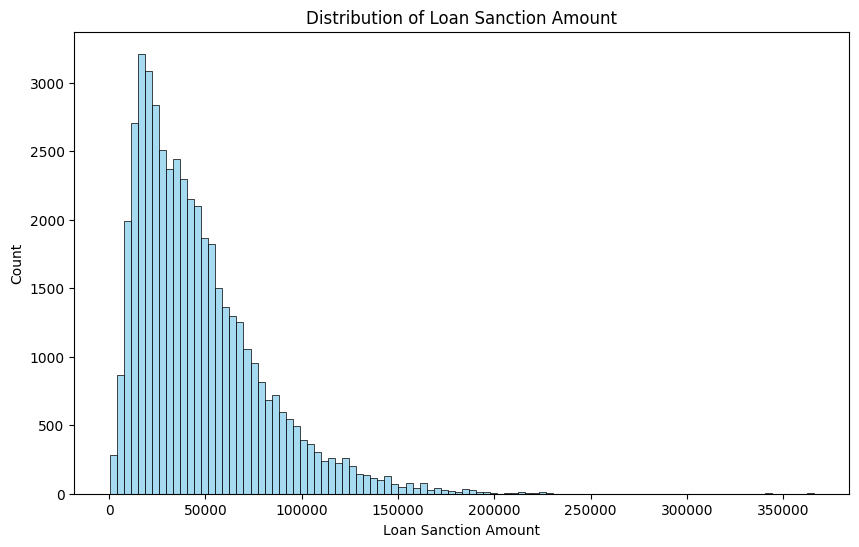

In [55]:
# histograms
plt.figure(figsize=(10, 6))
sns.histplot(df['Gender'], kde=False, bins=2, color='skyblue')
plt.title('Distribution of Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, bins=30, color='skyblue')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['Income (USD)'], kde=True, bins=100, color='skyblue')
plt.title('Distribution of Income')
plt.xlabel('Income')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['Income Stability'], kde=False, bins=2, color='skyblue')
plt.title('Distribution of Income Stability')
plt.xlabel('Income Stability')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['Property Age'], kde=False, bins=100, color='skyblue')
plt.title('Distribution of Property Age')
plt.xlabel('Property Age')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['Property Location'], kde=False, bins=3, color='skyblue')
plt.title('Distribution of Property Location')
plt.xlabel('Property Location')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['Property Price'], kde=False, bins=100, color='skyblue')
plt.title('Distribution of Property Price')
plt.xlabel('Property Price')
plt.ylabel('Count')
plt.show()

plt.figure(figsize=(10, 6))
sns.histplot(df['Loan Sanction Amount (USD)'], kde=False, bins=100, color='skyblue')
plt.title('Distribution of Loan Sanction Amount')
plt.xlabel('Loan Sanction Amount')
plt.ylabel('Count')
plt.show()

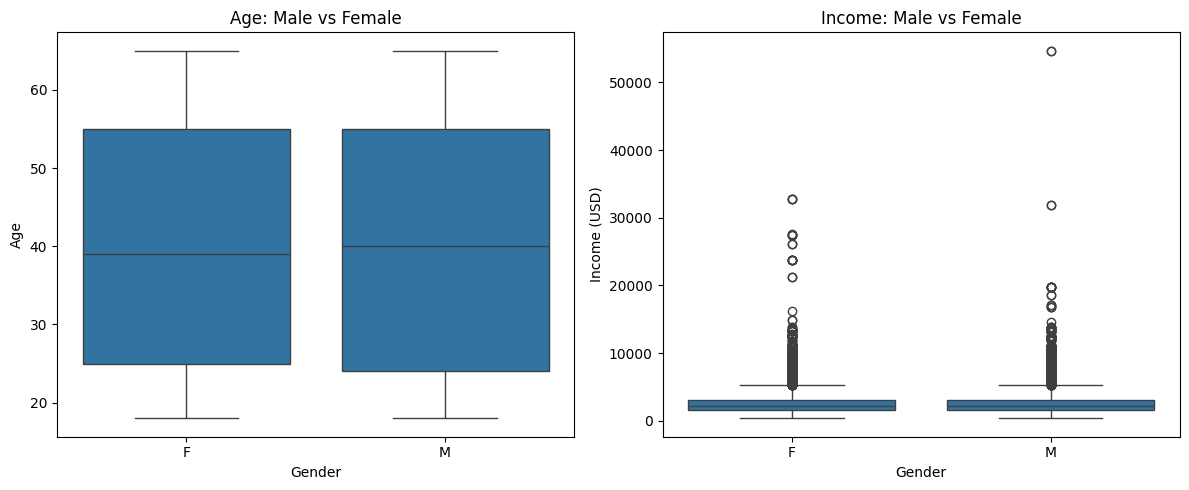

In [56]:
#boxplots
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(x='Gender', y='Age', data=df)
plt.title('Age: Male vs Female')

plt.subplot(1, 2, 2)
sns.boxplot(x='Gender', y='Income (USD)', data=df)
plt.title('Income: Male vs Female')

plt.tight_layout()
plt.show()

# 3. Normalize Data (Feature Engineering) to train linear regression model

In [57]:
def normalize_data(df):
  normalized_data = df.copy()
  normalized_data["Gender"] = normalized_data["Gender"].astype("category").cat.codes
  normalized_data["Income Stability"] = normalized_data["Income Stability"].astype("category").cat.codes
  normalized_data["Property Location"] = normalized_data["Property Location"].astype("category").cat.codes
  normalized_data["Age"] = zscore(normalized_data["Age"])
  normalized_data["Income (USD)"] = zscore(normalized_data["Income (USD)"])
  normalized_data["Property Age"] = zscore(normalized_data["Property Age"])
  normalized_data["Property Price"] = zscore(normalized_data["Property Price"])
  
  display(normalized_data.head())
  display(normalized_data.corr())
  return normalized_data

,Gender,Age,Income (USD),Income Stability,Property Age,Property Location,Property Price,Loan Sanction Amount (USD)
0,0,-1.305490,-0.606738,1,-0.600258,0,-0.797716,21026.420753
1,1,-0.683830,-0.383112,1,-0.382413,2,0.473372,60595.183366
2,0,-0.186502,-0.472829,1,-0.468278,0,-0.188104,39181.648002
3,1,1.554147,0.095298,0,0.103043,0,2.319041,128497.710865
4,0,1.367649,1.383045,0,1.382415,2,-0.560790,39386.919336


,Gender,Age,Income (USD),Income Stability,Property Age,Property Location,Property Price,Loan Sanction Amount (USD)
Gender,1.000000,0.007725,-0.002613,-0.019062,-0.002706,0.009106,0.005980,0.003493
Age,0.007725,1.000000,-0.044046,-0.455781,-0.044012,-0.007755,-0.003330,-0.000319
Income (USD),-0.002613,-0.044046,1.000000,0.080917,0.999973,-0.000158,0.357952,0.392658
Income Stability,-0.019062,-0.455781,0.080917,1.000000,0.080957,-0.001884,0.004823,-0.070777
Property Age,-0.002706,-0.044012,0.999973,0.080957,1.000000,-0.000216,0.357929,0.392591
Property Location,0.009106,-0.007755,-0.000158,-0.001884,-0.000216,1.000000,-0.000695,-0.001797
Property Price,0.005980,-0.003330,0.357952,0.004823,0.357929,-0.000695,1.000000,0.994240
Loan Sanction Amount (USD),0.003493,-0.000319,0.392658,-0.070777,0.392591,-0.001797,0.994240,1.000000


<Axes: >

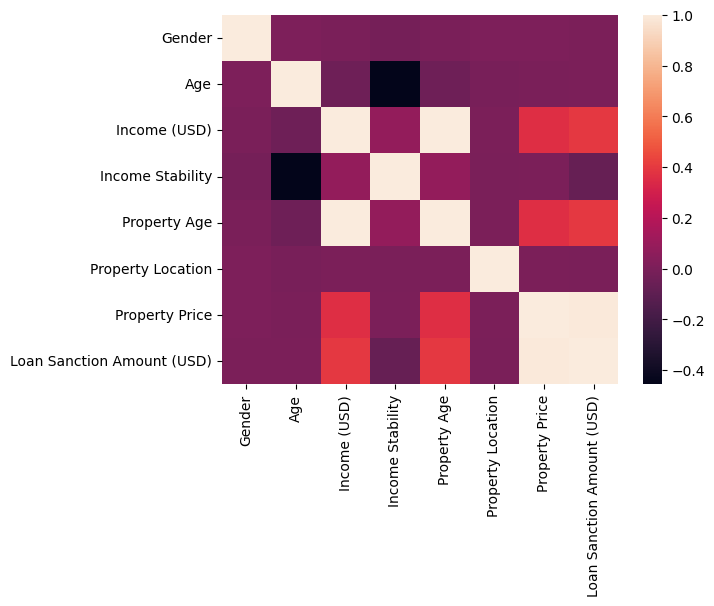

In [58]:
# Heatmap
normalized_data = normalize_data(df)
sns.heatmap(normalized_data.corr())

# 4. Train linear regression model and show the model's intercepts, coeficients

In [59]:
# Train-test split
columns = df.columns.tolist()
columns

['Gender',
 'Age',
 'Income (USD)',
 'Income Stability',
 'Property Age',
 'Property Location',
 'Property Price',
 'Loan Sanction Amount (USD)']

In [60]:
def prepare_X_y(df):
    ## Split X, y from dataset
    columns = df.columns.tolist()     # Columns name
    columns.remove('Loan Sanction Amount (USD)')           # Remove y label (column charges in this case)
    # columns = ["smoker_yes", "bmi", "age"]
    X = df[columns]        # X
    y = df['Loan Sanction Amount (USD)']          # y
    return X, y

X, y = prepare_X_y(normalized_data)

In [61]:
def split_train_test(X, y, train_size=0.7):
    trainX, testX ,trainY, testY = train_test_split(X, y, train_size=train_size, random_state=2026)
    print('Training:' + str(trainX.shape))
    print('Test:' + str(testX.shape))

    return trainX, testX ,trainY, testY

trainX, testX ,trainY, testY = split_train_test(X, y)

Training:(33107, 7)
Test:(14190, 7)


In [62]:
# Basic Linear Regression
def build_linear_model(X, y):
    model = linear_model.LinearRegression(fit_intercept=True)
    model.fit(X, y)

    return model

model = build_linear_model(trainX, trainY)
# Compare on training dataset
pred = model.predict(trainX)
print("mean absolute error of linear model on train set ", mean_absolute_error(y_pred=pred, y_true=trainY) )
pred = model.predict(testX)
print("mean absolute error of linear model on test set ", mean_absolute_error(y_pred=pred, y_true=testY) )
print("Model Coefficients:")
print(model.coef_) # print coefficient
print("Model Intercept:")
print(model.intercept_) # print intercept_


mean absolute error of linear model on train set  226.57007268056756
mean absolute error of linear model on test set  224.5563257769385
Model Coefficients:
[  -269.06129635  -1280.69124668  25850.74320946 -11143.70082733
 -24251.09785901    -64.36585635  31806.79484037]
Model Intercept:
56837.31231784763


# 5. Learn on sklearn how to use Ridge, Lasso, and ElasticNet compare the error of all 3 algorithms with Linear Regression (https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)

In [63]:

# Learn on sklearn how to use Ridge, Lasso, and ElasticNet compare the error of all 3 algorithms with Linear Regression 

# Ridge Regression
def build_ridge_model(X, y, alpha=1.0):
    model = linear_model.Ridge(alpha=alpha, fit_intercept=True)
    model.fit(X, y)

    return model

ridge = build_ridge_model(trainX, trainY, alpha=1.0)
# Compare on training dataset
predTrain = ridge.predict(trainX)
print("mean absolute error of ridge model on train set ", mean_absolute_error(y_pred=predTrain, y_true=trainY) )
predTest = ridge.predict(testX)
print("mean absolute error of ridge model on test set ", mean_absolute_error(y_pred=predTest, y_true=testY) )
print("Model Coefficients:")
print(ridge.coef_) # print coefficient
print("Model Intercept:")
print(ridge.intercept_) # print intercept_

# Compare with Linear Regression and Ridge Regression
print("Linear Regression vs Ridge Regression:")
diff = mean_absolute_error(y_pred=ridge.predict(testX), y_true=testY) - mean_absolute_error(y_pred=linear_model.LinearRegression().fit(trainX, trainY).predict(testX), y_true=testY)
print("Difference in mean absolute error (Ridge - Linear):", diff)


mean absolute error of ridge model on train set  194.2686014863681
mean absolute error of ridge model on test set  193.07333599650983
Model Coefficients:
[  -265.83993676  -1280.62488935  13755.6671518  -11141.03395816
 -12155.98347596    -63.38529125  31806.05488267]
Model Intercept:
56832.58623741309
Linear Regression vs Ridge Regression:
Difference in mean absolute error (Ridge - Linear): -31.48298978042868


In [64]:

# Lasso Regression
def build_lasso_model(X, y, alpha=1.0):
    model = linear_model.Lasso(alpha=alpha, fit_intercept=True, max_iter=10000, tol=0.01)
    model.fit(X, y) 
    
    return model

lasso = build_lasso_model(trainX, trainY, alpha=1.0)
# Compare on training dataset
predTrain = lasso.predict(trainX)
print("mean absolute error of lasso model on train set ", mean_absolute_error(y_pred=predTrain, y_true=trainY) )
predTest = lasso.predict(testX)
print("mean absolute error of lasso model on test set ", mean_absolute_error(y_pred=predTest, y_true=testY) )
print("Model Coefficients:")
print(lasso.coef_) # print coefficient
print("Model Intercept:")
print(lasso.intercept_) # print intercept_

# Compare with Linear Regression and Lasso Regression
print("Linear Regression vs Lasso Regression:")
diff = mean_absolute_error(y_pred=lasso.predict(testX), y_true=testY) - mean_absolute_error(y_pred=linear_model.LinearRegression().fit(trainX, trainY).predict(testX), y_true=testY)
print("Difference in mean absolute error (Lasso - Linear):", diff)


mean absolute error of lasso model on train set  178.15440066549348
mean absolute error of lasso model on test set  177.7515958519659
Model Coefficients:
[  -255.68834389  -1257.06360813   1378.46716004 -11102.17547136
    244.28375167    -60.83435945  31797.88750978]
Model Intercept:
56789.98350187356
Linear Regression vs Lasso Regression:
Difference in mean absolute error (Lasso - Linear): -46.804729924972605


In [65]:
# ElasticNet Regression
def build_elasticnet_model(X, y, alpha=1.0, l1_ratio=1):
    model = linear_model.ElasticNet(alpha=alpha, l1_ratio=l1_ratio, fit_intercept=True, max_iter=10000, tol=0.01)
    model.fit(X, y)
    
    return model

elasticnet = build_elasticnet_model(trainX, trainY, alpha=1.0, l1_ratio=1)
# Compare on training dataset
predTrain = elasticnet.predict(trainX)
print("mean absolute error of elasticnet model on train set ", mean_absolute_error(y_pred=predTrain, y_true=trainY) )
predTest = elasticnet.predict(testX)
print("mean absolute error of elasticnet model on test set ", mean_absolute_error(y_pred=predTest, y_true=testY) )
print("Model Coefficients:")
print(elasticnet.coef_) # print coefficient
print("Model Intercept:")
print(elasticnet.intercept_) # print intercept_

# Compare with Linear Regression and ElasticNet Regression
print("Linear Regression vs ElasticNet Regression:")
diff = mean_absolute_error(y_pred=elasticnet.predict(testX), y_true=testY) - mean_absolute_error(y_pred=linear_model.LinearRegression().fit(trainX, trainY).predict(testX), y_true=testY)
print("Difference in mean absolute error (ElasticNet - Linear):", diff)


mean absolute error of elasticnet model on train set  178.15440066549348
mean absolute error of elasticnet model on test set  177.7515958519659
Model Coefficients:
[  -255.68834389  -1257.06360813   1378.46716004 -11102.17547136
    244.28375167    -60.83435945  31797.88750978]
Model Intercept:
56789.98350187356
Linear Regression vs ElasticNet Regression:
Difference in mean absolute error (ElasticNet - Linear): -46.804729924972605


**Extra:** Finding best parameters for Ridge, Lasso, and ElasticNet 

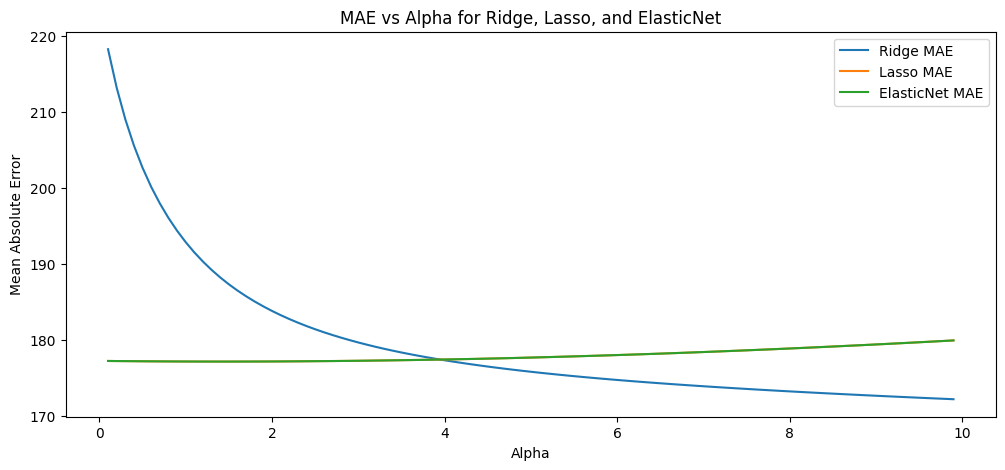

Best alpha for Ridge: 9.90, best MAE: 172.2273, improvement over Linear: 52.3291
Best alpha for Lasso: 1.50, best MAE: 177.1831, improvement over Linear: 47.3733
Best alpha for ElasticNet: 1.50, best MAE: 177.1831, improvement over Linear: 47.3733


In [66]:
# Create an 'alphas' variable so we only have to define this range once
alphas = np.arange(0.1, 10, 0.1)

mae_ridge = []
mae_lasso = []
mae_elasticnet = []
# Scaling data
scaler = StandardScaler()
trainX_scaled = scaler.fit_transform(trainX)
testX_scaled = scaler.transform(testX)

# --- 1. Loop through alphas (CRITICAL: Using scaled data!) ---
for i in alphas:
    ridge = build_ridge_model(trainX_scaled, trainY, alpha=i)
    predTest = ridge.predict(testX_scaled)
    mae_ridge.append(mean_absolute_error(y_pred=predTest, y_true=testY))
    
    lasso = build_lasso_model(trainX_scaled, trainY, alpha=i)
    predTest = lasso.predict(testX_scaled)
    mae_lasso.append(mean_absolute_error(y_pred=predTest, y_true=testY))
    
    # Note: Because l1_ratio=1, this is mathematically just a Lasso model.
    # Change it to 0.5 if you want to see a blend of Ridge and Lasso!
    elasticnet = build_elasticnet_model(trainX_scaled, trainY, alpha=i, l1_ratio=1)
    predTest = elasticnet.predict(testX_scaled)
    mae_elasticnet.append(mean_absolute_error(y_pred=predTest, y_true=testY))
    
# --- 2. Plotting (Using the 'alphas' variable) ---
plt.figure(figsize=(12, 5))
plt.plot(alphas, mae_ridge, label='Ridge MAE')
plt.plot(alphas, mae_lasso, label='Lasso MAE')
plt.plot(alphas, mae_elasticnet, label='ElasticNet MAE')
plt.xlabel('Alpha')
plt.ylabel('Mean Absolute Error')
plt.title('MAE vs Alpha for Ridge, Lasso, and ElasticNet')
plt.legend()
plt.show()

# --- 3. Find best alpha for Ridge, Lasso, and ElasticNet ---
best_alpha_ridge = alphas[np.argmin(mae_ridge)]
best_alpha_lasso = alphas[np.argmin(mae_lasso)]
best_alpha_elasticnet = alphas[np.argmin(mae_elasticnet)]

# --- 4. Compute best MAE vs Baseline ---
best_mae_ridge = min(mae_ridge)
best_mae_lasso = min(mae_lasso)
best_mae_elasticnet = min(mae_elasticnet)

# Train the baseline Linear Regression on scaled data for a fair comparison
baseline_model = linear_model.LinearRegression().fit(trainX_scaled, trainY)
mae_linear = mean_absolute_error(y_pred=baseline_model.predict(testX_scaled), y_true=testY)

# Use formatting (:.4f) to keep the print statements clean and readable
print(f"Best alpha for Ridge: {best_alpha_ridge:.2f}, best MAE: {best_mae_ridge:.4f}, improvement over Linear: {mae_linear - best_mae_ridge:.4f}")
print(f"Best alpha for Lasso: {best_alpha_lasso:.2f}, best MAE: {best_mae_lasso:.4f}, improvement over Linear: {mae_linear - best_mae_lasso:.4f}")
print(f"Best alpha for ElasticNet: {best_alpha_elasticnet:.2f}, best MAE: {best_mae_elasticnet:.4f}, improvement over Linear: {mae_linear - best_mae_elasticnet:.4f}")

Như vậy giữa các phương pháp Ridge, Lasso, và ElasticNet thì cả 3 đều có thể cải thiện hiệu suất của mô hình so với Linear Regression.

## Polynomial Transform

When the data feature does not conform to a linear function, a linear regression cannot be applied directly to the original data. Then, there are many possibilities that the data feature conforms to the polynomial function. Scikit-Learn supports converting data features to polynomials through ``PolynomialFeatures``.

$$
y = a_0 + a_1 x + a_2 x^2 + a_3 x^3 + \cdots
$$

The formula above uses the transformation of the value $x$ from one dimension to the other, with the aim of being able to use linear regression to find complex relationships between $x$ and $y$.

In [67]:
#Linear Regression with Polynomial Transform
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

def build_pipeline(X, y):
    poly_model = make_pipeline(PolynomialFeatures(2, include_bias=False), linear_model.LinearRegression()) # use make_pipeline to apply PolynomialFeatures and a Regression model train your dataset
    poly_model.fit(X, y)  

    return poly_model

poly_model = build_pipeline(trainX, trainY)
# Compare on training dataset
poly_pred = poly_model.predict(trainX)   
print("mean absolute error of linear model (with poly transform) on train set ", mean_absolute_error(y_pred=poly_pred, y_true=trainY) )

poly_pred = poly_model.predict(testX)
print("mean absolute error of linear model (with poly transform) on test set ", mean_absolute_error(y_pred=poly_pred, y_true=testY))

mean absolute error of linear model (with poly transform) on train set  154.94268406042352
mean absolute error of linear model (with poly transform) on test set  154.20644067428057


degree of PolynomialFeatures function is defined by a tuple (x, y) where x is the smallest degree, y is the largest degree, if we only input 1 value t, the function will understand x = 0 and y = t

> Indented block
* if the 2nd order with 1 feature is $X_1$ then the equation is of the form:
$$\theta_0 + \theta_1*X_1+\theta_2*X_1^2$$
* if the 2nd order with 2 features is $X_1$ and $X_2$ then the equation is of the form:
$$\theta_0 + \theta_1*X_1+\theta_2*X_2+\theta_3*X_1^2 + \theta_4*X_2^2 + \theta_5*X_1*X_2$$

In [68]:
# --- To get output of polynomial model
# We can call its name
linear_model = poly_model["linearregression"]
# or by number
linear_model = poly_model[1]

In [69]:
linear_model.coef_

array([-1.11733313e+02, -1.27623848e+03,  1.28600019e+03, -5.57136347e+03,
        3.06175706e+02, -4.95282642e+02,  3.18248746e+04, -1.11733313e+02,
       -4.94734977e+00, -5.70015118e+02, -3.02160953e+01,  5.46137474e+02,
       -1.38085536e+01, -4.04564095e+00, -3.75069945e-01, -2.09470091e+02,
       -2.15910301e+01,  2.13927329e+02,  2.21628163e+01, -2.93474468e+01,
        3.89562392e+04, -1.87411652e+02, -7.74347556e+04,  1.81692201e+02,
        1.28226289e+02, -5.57136347e+03,  2.17698062e+02,  4.52189347e+01,
       -1.55109352e+01,  3.84777977e+04, -1.82474545e+02, -1.36339469e+02,
        1.99375290e+02,  5.77723186e+00, -4.45118278e+00])

In [70]:
linear_model.intercept_

np.float64(56897.41390509074)

In [73]:
pred = model.predict(trainX)
poly_pred = poly_model.predict(trainX)   
print("mean absolute error of linear model on train set ", mean_absolute_error(y_pred=pred, y_true=trainY))
print("mean absolute error of linear model (with poly transform) on train set ", mean_absolute_error(y_pred=poly_pred, y_true=trainY))


print("difference in mean absolute error (Linear - Linear with Poly):", mean_absolute_error(y_pred=pred, y_true=trainY) - mean_absolute_error(y_pred=poly_pred, y_true=trainY) )

mean absolute error of linear model on train set  226.57007268056756
mean absolute error of linear model (with poly transform) on train set  154.94268406042352
difference in mean absolute error (Linear - Linear with Poly): 71.62738862014405


In [72]:

from sklearn.manifold import TSNE

# Split X, y from dataset
columns = df.columns.tolist()     # Columns name
draw_data = df[columns]        # X 
draw_data = TSNE(n_components=1, learning_rate='auto', init='random', perplexity=3).fit_transform(draw_data)


from sklearn.model_selection import train_test_split
draw_train_X, draw_test_X ,trainY, testY = train_test_split(draw_data, target, train_size=0.70, random_state=2023)
print('Training:' + str(draw_train_X.shape))
print('Test:' + str(draw_test_X.shape))
     

ValueError: could not convert string to float: 'F'

In [ ]:
#model basic 
model = LinearRegression(fit_intercept=True)   
model.fit(draw_train_X, trainY)
pred = model.predict(draw_train_X)
print("mean absolute error of linear model on train set ", mean_absolute_error(y_pred=pred, y_true=trainY) )

#model polinomial 
poly_model = make_pipeline(PolynomialFeatures(2, include_bias=False), LinearRegression())
poly_model.fit(draw_train_X, trainY)
poly_pred = poly_model.predict(draw_train_X)
print("mean absolute error of linear model (with poly transform) on train set ", mean_absolute_error(y_pred=poly_pred, y_true=trainY) )
     

In [ ]:
import matplotlib.pyplot as plt

# pred = model.predict(trainX)
# poly_pred = poly_model.predict(trainX)

plt.scatter(draw_train_X, trainY, color="g")
plt.plot(draw_train_X, pred, color="blue", linewidth=3)
plt.plot(draw_train_X, poly_pred, color="yellow", linewidth=3)
plt.xticks(())
plt.yticks(())

plt.show()

#Exercise
This is a dataset related to how much money a person can get from a mortgage on his or her home. This dataset includes the following features:
* Gender: Gender of the borrower (including two values 'F' and 'M')
* Age: Age of the customer applying for a loan (including positive integer values)
* Income (USD): Customer's income in USD (value is a positive number)
* Income Stability: The level of customer's income stability (including three values of Low and High)
* Property Age: Life expectancy of the house in days (including positive integer values)
* Property Location: Location of the house (including 'Rural', 'Urban', and 'Semi-Urban')
* Property Price: The value of the house in USD (including positive real values)
* Loan Sanction Amount (USD): Amount that customers can borrow in USD (target value)

Based on practice sample #1, proceed:
1. Read data
2. Visualize some information of data
3. Normalize Data (Feature Engineering) to train linear regression model
4. Train linear regression model and show the model's intercepts, coeficients
5. Learn on sklearn how to use Ridge, Lasso, and ElasticNet compare the error of all 3 algorithms with Linear Regression (https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html)
6. Let's try Polynomial of order 2 to compare the previous results. What will the result be if we choose the n order too high?


**Submission Link**: https://forms.gle/uKAq34QrbwTcbs5Z9 (Submit your .ipynb file)